In [7]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [8]:
case_date = '20181129'
ensmember = 'gefs09'

# Data directories
dir_native = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/{case_date}/{ensmember}/base/d4_native/stats/'
dir_d4 = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/{case_date}/{ensmember}/base/d4/stats/'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/lasso_d4_resolution_test/'

os.makedirs(figdir, exist_ok=True)

in_basename = 'domain_timeseries_cellstats_'

# Find files
files_native = sorted(glob.glob(f'{dir_native}{in_basename}*.nc'))
files_d4 = sorted(glob.glob(f'{dir_d4}{in_basename}*.nc'))
print(f'Number of native 100m files: {len(files_native)}')
print(f'Number of 100m->500m files: {len(files_d4)}')
files_native, files_d4

Number of native 100m files: 1
Number of 100m->500m files: 1


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs09/base/d4_native/stats/domain_timeseries_cellstats_20181129.1200_20181130.0000.nc'],
 ['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs09/base/d4/stats/domain_timeseries_cellstats_20181129.1200_20181130.0000.nc'])

In [9]:
ds_native = xr.open_dataset(files_native[0])
ds_d4 = xr.open_dataset(files_d4[0])
ds_native

<xarray.Dataset> Size: 6kB
Dimensions:             (time: 145, quantile: 3)
Coordinates:
  * time                (time) datetime64[ns] 1kB 2018-11-29T12:00:00 ... 201...
  * quantile            (quantile) float64 24B 0.25 0.5 0.75
Data variables:
    echotop10_mean      (time) float32 580B ...
    echotop10_quantile  (quantile, time) float32 2kB ...
    cellarea_mean       (time) float32 580B ...
    cellarea_quantile   (quantile, time) float32 2kB ...
    ncells              (time) float32 580B ...
Attributes:
    Title:        Domain cell statistics time-series
    startdate:    20181129.1200
    enddate:      20181130.0000
    ensmember:    gefs09
    domain:       d4
    Contact:      Zhe Feng: zhe.feng@pnnl.gov
    Institution:  Pacific Northwest National Laboratory
    created on:   Sat Apr 25 03:04:54 2026

In [10]:
# Convert cell area to equivalent diameter
diam_qnt_native = 2 * np.sqrt(ds_native.cellarea_quantile)
diam_qnt_d4 = 2 * np.sqrt(ds_d4.cellarea_quantile)

# Convert ETH units from [m] to [km]
eth10_qnt_native = ds_native.echotop10_quantile / 1000
eth10_qnt_d4 = ds_d4.echotop10_quantile / 1000

ncells_native = ds_native.ncells
ncells_d4 = ds_d4.ncells

## Plotting function

In [11]:
def plot_allens(ncol, da_lines, da_shade,
                wspace=None, hspace=None, top=None, suptitle=None, suptitle_y=None, invert_yaxis=None,
                xlims=None, ylims=None, xlabels=None, ylabels=None, legend_fs=None, legend_show=None,
                titles=None, fontsize=None, figsize=None, figname=None, dpi=None):
    """
    Plot domain-mean cell statistics time series for two resolutions.

    Args:
        ncol: int
            Number of panels (columns).
        da_lines: list of dict
            Each element is a dict with keys 'native' and 'd4', each a DataArray
            containing the median time series for that panel.
        da_shade: list of dict or None
            Each element is a dict with keys 'native' and 'd4', each containing
            a sub-dict {'lo': DataArray, 'hi': DataArray} for the IQR shading.
            Use None for panels with no shading (e.g., ncells).
    """
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    time_fmt = mdates.DateFormatter('%H')

    lw = 2
    lcolors = {'native': 'darkviolet', 'd4': 'seagreen'}
    llabels = {'native': 'GEFS09 (native 100m)', 'd4': r'GEFS09 (100m$\rightarrow$500m)'}

    fig = plt.figure(figsize=figsize, dpi=dpi)
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpec(1, ncol, figure=fig, height_ratios=[1], width_ratios=w_ratios,
                           wspace=wspace, hspace=hspace, top=top)

    for col in range(ncol):
        da_l = da_lines[col]
        if da_l is not None:
            da_s = da_shade[col]
            ax = plt.subplot(gs[0, col])

            # Plot median lines
            for key in ['native', 'd4']:
                ax.plot(da_l[key].time, da_l[key].values, color=lcolors[key], lw=lw, zorder=2, label=llabels[key])

            # Plot shaded IQR
            if da_s is not None:
                for key in ['native', 'd4']:
                    ax.fill_between(da_s[key]['lo'].time, da_s[key]['lo'], da_s[key]['hi'],
                                    facecolor=lcolors[key], alpha=0.2, zorder=1)

            if legend_show[col]:
                ax.legend(loc='best', fontsize=legend_fs)
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
            ax.xaxis.set_major_formatter(time_fmt)
            ax.grid(ls=':')
            if xlims is not None:
                ax.set_xlim(xlims[0], xlims[1])
            if ylims is not None:
                ax.set_ylim(ylims[col][0], ylims[col][1])
            if invert_yaxis is not None:
                if invert_yaxis[col]:
                    ax.invert_yaxis()
            if titles is not None:
                ax.set_title(titles[col], loc='left')
            if xlabels is not None:
                ax.set_xlabel(xlabels[col])
            if ylabels is not None:
                ax.set_ylabel(ylabels[col])

    if suptitle is not None:
        fig.suptitle(suptitle, y=suptitle_y, weight='bold')
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

## Plot: native 100m vs coarsened 500m

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/lasso_d4_resolution_test/domain_timeseries_cellstats_20181129_GEFS09_d4_native_vs_coarsen.png


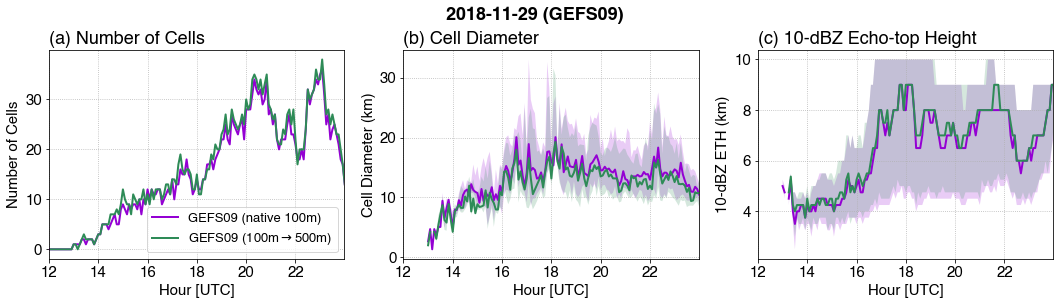

In [12]:
ncol = 3

da_lines = [
    {'native': ncells_native, 'd4': ncells_d4},
    {'native': diam_qnt_native.sel(quantile=0.5), 'd4': diam_qnt_d4.sel(quantile=0.5)},
    {'native': eth10_qnt_native.sel(quantile=0.5), 'd4': eth10_qnt_d4.sel(quantile=0.5)},
]

da_shade = [
    None,
    {'native': {'lo': diam_qnt_native.sel(quantile=0.25), 'hi': diam_qnt_native.sel(quantile=0.75)},
     'd4':     {'lo': diam_qnt_d4.sel(quantile=0.25),     'hi': diam_qnt_d4.sel(quantile=0.75)}},
    {'native': {'lo': eth10_qnt_native.sel(quantile=0.25), 'hi': eth10_qnt_native.sel(quantile=0.75)},
     'd4':     {'lo': eth10_qnt_d4.sel(quantile=0.25),     'hi': eth10_qnt_d4.sel(quantile=0.75)}},
]

time_s = pd.to_datetime(f'{case_date}T12', format='%Y%m%dT%H')
time_e = time_s.replace(hour=23, minute=59)
date_fmt = time_s.strftime('%Y-%m-%d')
xlims = [time_s, time_e]

ylims = None
invert_yaxis = [False, False, False]
xlabels = ['Hour [UTC]'] * ncol
ylabels = ['Number of Cells', 'Cell Diameter (km)', '10-dBZ ETH (km)']
titles = ['(a) Number of Cells', '(b) Cell Diameter', '(c) 10-dBZ Echo-top Height']
suptitle = f'{date_fmt} ({ensmember.upper()})'
suptitle_y = 0.999

legend_show = [True, False, False]
legend_fs = 13
fontsize = 15
figsize = (18, 4)
wspace = 0.2
figname = f'{figdir}domain_timeseries_cellstats_{case_date}_{ensmember.upper()}_d4_native_vs_coarsen.png'
print(figname)

fig = plot_allens(ncol, da_lines, da_shade, xlims=xlims, xlabels=xlabels, ylims=ylims, ylabels=ylabels,
                  titles=titles, suptitle=suptitle, suptitle_y=suptitle_y, invert_yaxis=invert_yaxis,
                  wspace=wspace, top=0.85,
                  legend_fs=legend_fs, legend_show=legend_show,
                  fontsize=fontsize, figsize=figsize, figname=figname)